Import library yang dibutuhkan


In [22]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re

Import dataset mentah


In [7]:
df = pd.read_csv('../datasets/surat_uncleaned.csv')
df.head()

,property_name,areaWithType,square_feet,transaction,status,floor,furnishing,facing,description,price_per_sqft,price
0,2 BHK Apartment for Sale in Dindoli Surat,Carpet Area,644 sqft,New Property,Poss. by Oct '24,5 out of 10,Unfurnished,West,"Luxury project with basement parking, Solar ro...","₹2,891 per sqft",₹33.8 Lac
1,2 BHK Apartment for Sale in Althan Surat,Super Area,1278 sqft,New Property,Poss. by Jan '26,6 out of 14,Unfurnished,South -West,2 And 3 BHK Luxurious Flat for Sell In New Alt...,"₹3,551 per sqft",₹45.4 Lac
2,2 BHK Apartment for Sale in Pal Gam Surat,Super Area,1173 sqft,Resale,Ready to Move,5 out of 13,Semi-Furnished,East,This affordable 2 BHK flat is situated along a...,"₹3,800 per sqft",₹44.6 Lac
3,2 BHK Apartment for Sale in Jahangirabad Surat,Carpet Area,700 sqft,New Property,Ready to Move,6 out of 14,Unfurnished,East,2 BHK Flat For sell IN Jahangirabad Prime Loca...,"₹3,966 per sqft",₹47 Lac
4,"2 BHK Apartment for Sale in Orchid Fantasia, P...",Super Area,1250 sqft,Orchid Fantasia,New Property,Unfurnished,2,2,"Multistorey Apartment for Sale in Palanpur, Su...","₹3,600 per sqft",₹45 Lac


Cek informasi dataset


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4525 entries, 0 to 4524
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   property_name   4525 non-null   object
 1   areaWithType    4525 non-null   object
 2   square_feet     4525 non-null   object
 3   transaction     4421 non-null   object
 4   status          4524 non-null   object
 5   floor           4480 non-null   object
 6   furnishing      4185 non-null   object
 7   facing          3936 non-null   object
 8   description     3154 non-null   object
 9   price_per_sqft  4157 non-null   object
 10  price           4525 non-null   object
dtypes: object(11)
memory usage: 389.0+ KB


Cek jumlah missing value


In [4]:
df.isnull().sum()

property_name        0
areaWithType         0
square_feet          0
transaction        104
status               1
floor               45
furnishing         340
facing             589
description       1371
price_per_sqft     368
price                0
dtype: int64

Cek jumlah data duplikat


In [5]:
print(f"Duplikat data: {df.duplicated().sum()}")

Duplikat data: 109


Analisis apakahh benar terisi object -> trnyt msh byk mengandung karakter non numerik spt simmbol mata uang, satuan, dan koma


In [8]:
print(df[['price', 'square_feet', 'price_per_sqft']].head())

        price square_feet    price_per_sqft
0  ₹33.8 Lac     644 sqft  ₹2,891 per sqft 
1  ₹45.4 Lac    1278 sqft  ₹3,551 per sqft 
2  ₹44.6 Lac    1173 sqft  ₹3,800 per sqft 
3    ₹47 Lac     700 sqft  ₹3,966 per sqft 
4    ₹45 Lac    1250 sqft  ₹3,600 per sqft 


Consistency check -> hasilnya kemungkinan ada outlier


In [9]:
temp_price = pd.to_numeric(df['price'].str.replace(r'[^0-9.]', '', regex=True), errors='coerce')
print(f"Harga Minimum: {temp_price.min()}")

Harga Minimum: 1.0


In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)
#dari hasilnya description paling banyak data kosong nya sehingga dianggap tidak lengkap

property_name      0.000000
areaWithType       0.000000
square_feet        0.000000
transaction        2.298343
status             0.022099
floor              0.994475
furnishing         7.513812
facing            13.016575
description       30.298343
price_per_sqft     8.132597
price              0.000000
dtype: float64


Pre-cleaning: Sinkroniasai nilai & type casting


In [19]:
def convert_price(value):
    if pd.isna(value): return np.nan
    value = str(value).replace('₹', '').replace(',', '').strip()
    match = re.search(r'([\d.]+)\s*(Lac|Cr)?', value) #1 Lac = 100 ribu rupe, 1Cr (crore)  = 10jt rupee
    if match:
        number = float(match.group(1))
        unit = match.group(2)
        if unit =="Lac": return number * 100000
        if unit =='Cr': return number * 10000000
        return number
    return np.nan
# 1. Konversi Kolom Price
df['price'] = df['price'].apply(convert_price)

# 2. Konversi Kolom Square Feet & Price per Sqft (Hapus semua kecuali angka dan titik)
df['square_feet'] = pd.to_numeric(df['square_feet'].astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce')
df['price_per_sqft'] = pd.to_numeric(df['price_per_sqft'].astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce')

# 3. VERIFIKASI: Harus muncul float64 di sini
print(df[['price', 'square_feet', 'price_per_sqft']].dtypes)


price             float64
square_feet       float64
price_per_sqft    float64
dtype: object


In [20]:
print("Nilai Kemiringan Data (Skewness):")
print(df[['price', 'square_feet', 'price_per_sqft']].skew())

Nilai Kemiringan Data (Skewness):
price             56.707195
square_feet       66.245899
price_per_sqft    64.192997
dtype: float64


Data Cleaning

In [ ]:
# 1. Imputasi dengan Median (Justifikasi: Skewness > 1)
df['price'] = df['price'].fillna(df['price'].median())
df['square_feet'] = df['square_feet'].fillna(df['square_feet'].median())
df['price_per_sqft'] = df['price_per_sqft'].fillna(df['price_per_sqft'].median())

# 2. Imputasi Kategorikal (Sesuai catatan dosen: MAR/MNAR beri label baru)
df['furnishing'] = df['furnishing'].fillna('Unknown')
df['facing'] = df['facing'].fillna('Unknown')
df['transaction'] = df['transaction'].fillna(df['transaction'].mode()[0])
df['status'] = df['status'].fillna(df['status'].mode()[0])

df['floor'] = df['floor'].fillna(df['floor'].mode()[0])

# 2. Imputasi Description dengan label (agar dataset lengkap/complete)
df['description'] = df['description'].fillna('No Description')

# 3. Cek apakah missing value sudah 0
print(df.isnull().sum())

property_name     0
areaWithType      0
square_feet       0
transaction       0
status            0
floor             0
furnishing        0
facing            0
description       0
price_per_sqft    0
price             0
dtype: int64
property_name     0
areaWithType      0
square_feet       0
transaction       0
status            0
floor             0
furnishing        0
facing            0
description       0
price_per_sqft    0
price             0
dtype: int64


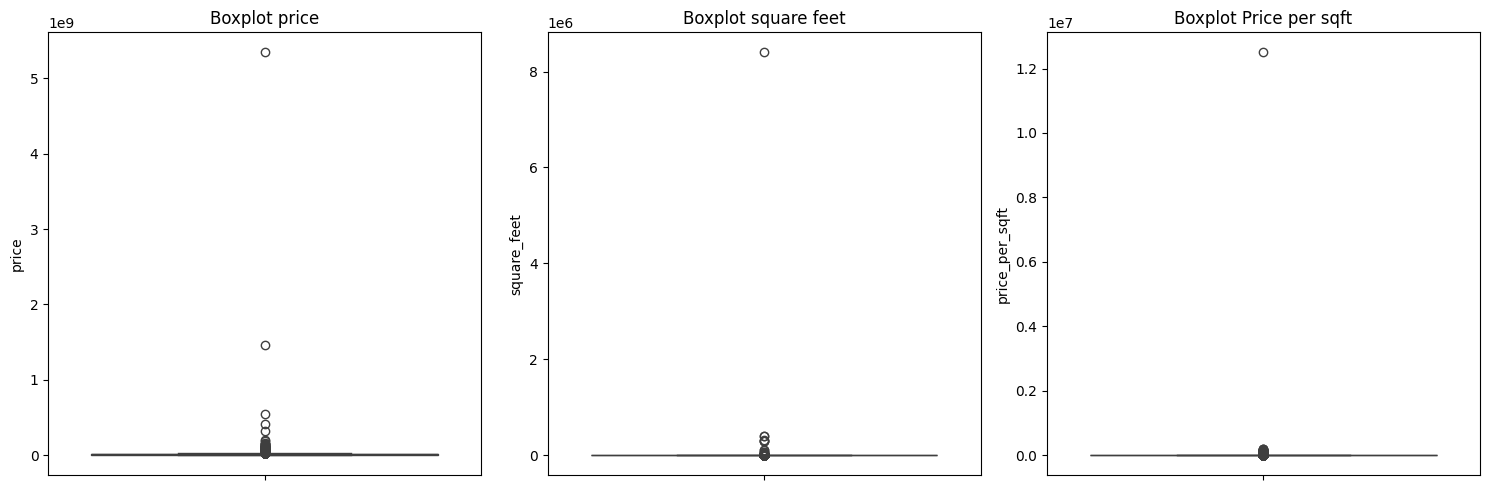

In [28]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(y=df['price'])
plt.title('Boxplot price')

plt.subplot(1,3,2)
sns.boxplot(y=df['square_feet'])
plt.title('Boxplot square feet')

plt.subplot(1,3,3)
sns.boxplot(y=df['price_per_sqft'])
plt.title('Boxplot Price per sqft')
plt.tight_layout()
plt.show()

In [26]:
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# Mari kita cek batas untuk Price
low_p, up_p = detect_outliers_iqr(df['price'])
print(f"Batas Bawah Harga: {low_p}, Batas Atas Harga: {up_p}")

# Cek berapa banyak data di atas batas atas
outliers_count = df[df['price'] > up_p].shape[0]
print(f"Jumlah Outlier di atas batas: {outliers_count}")

Batas Bawah Harga: -8425000.0, Batas Atas Harga: 25855000.0
Jumlah Outlier di atas batas: 383


In [24]:
# Cek harga yang tidak masuk akal (misal di bawah 100.000 Rupee)
noise_price = df[df['price'] < 100000]
print(f"Jumlah data harga tidak valid: {len(noise_price)}")

# Cek luas yang tidak masuk akal (misal di bawah 100 sqft untuk apartemen)
noise_area = df[df['square_feet'] < 100]
print(f"Jumlah data luas tidak valid: {len(noise_area)}")

Jumlah data harga tidak valid: 0
Jumlah data luas tidak valid: 83


In [25]:
# Cek nilai unik di kolom furnishing dan facing
print("Unique Furnishing:", df['furnishing'].unique())
print("Unique Facing:", df['facing'].unique())

Unique Furnishing: ['Unfurnished' 'Semi-Furnished' '2' 'Anand Aspire' 'East' '1' 'Furnished'
 'Unknown' '3' '1 Covered,' '2 Covered' '1 Covered' 'Freehold' 'West'
 '26 Covered' 'Main Road' 'No' 'North' '1 Open' '6' 'Co-operative Society'
 '> 10' '4' 'Nilkanth Seven Homes' 'Aagam Navkar' '10 Open'
 'Vinayak Enclave' '5 Covered,' 'South -West'
 'Pool, Garden/Park, Main Road' 'Garden/Park, Main Road' '7 m' '30 m'
 '50 Covered,' 'South' '12 m' 'Yes' 'Gruham Luxuria' '2 Covered,' 'Congo'
 'Prayosha Shine' 'North - East' 'Vaishnodevi Ideal Homes' 'Santvan Lexon'
 'Sangini Epitome' '100 Covered' 'Nirvana Gladiolus' '7' '5 Covered' '5'
 'Raghuvir Spalex' '50 Open' 'South - East' 'North - West' '20 m'
 '20 Open' 'Garden/Park' '10 m' 'Sattvam' 'Pramukh Amaya' 'Sun Sarvam'
 '3 Covered' '2 Open' '6 m' 'Avadh Kimberly' 'Happy Glorious' 'DMD Aura'
 'Freedom Tower' '15 m' 'Surya Signature' 'Someshwara Enclave'
 'Green Valley Row House' 'Green Valley' 'Vatsalya Bungalows' 'DMD Signus'
 '10 Covered,' '

Handling Outlier

In [29]:
from scipy.stats.mstats import winsorize

# 1. Trimming: Hapus luas yang tidak logis (< 100 sqft)
df = df[df['square_feet'] >= 100]

# 2. Winsorizing: Capping nilai ekstrem pada persentil 99
# limits=[0, 0.01] artinya kita membatasi 1% data teratas
df['price'] = winsorize(df['price'], limits=[0, 0.01])
df['square_feet'] = winsorize(df['square_feet'], limits=[0, 0.01])
df['price_per_sqft'] = winsorize(df['price_per_sqft'], limits=[0, 0.01])

# 3. Cek Skewness lagi setelah handling
print("Skewness setelah Handling Outlier:")
print(df[['price', 'square_feet', 'price_per_sqft']].skew())

Skewness setelah Handling Outlier:
price             2.828737
square_feet       2.198727
price_per_sqft    2.821211
dtype: float64


Cek data imbalance atau balance

In [30]:
print(df['transaction'].value_counts(normalize=True) * 100)
print("-" * 30)
print(df['status'].value_counts(normalize=True) * 100)

transaction
Resale                          50.765421
New Property                    33.385862
Unfurnished                      8.734804
Semi-Furnished                   1.778478
Furnished                        1.440792
2                                0.540297
3                                0.495272
No                               0.427735
Congo                            0.427735
1                                0.360198
Yes                              0.337686
5                                0.247636
4                                0.157587
Main Road                        0.135074
Soham Elegance                   0.067537
Orchid Gardenia                  0.067537
6                                0.067537
Orchid Fantasia                  0.045025
Jolly Residency                  0.045025
Raghuvir Silverstone             0.045025
Casa Rivera                      0.045025
Main Road, Garden/Park           0.022512
1 Covered                        0.022512
Other                 

Normalisasi

In [31]:
from sklearn.preprocessing import StandardScaler

# 1. Pilih fitur numerik
features = ['price', 'square_feet', 'price_per_sqft', 'floor']
X = df[features]

# 2. Standarisasi (Z-score scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Sekarang X_scaled siap dimasukkan ke DBSCAN

ValueError: could not convert string to float: '5 out of 10'